# Project 1: Physics

In this project you implement a **2D elastoplastic finite-element solver** with the
modern **FEniCSx** (`dolfinx`) package and use it to simulate a square specimen under
load-controlled bending.

The solver you complete here is **reused in Projects 2 and 3** — those notebooks import
`FenicsInterface` directly from this notebook, so make sure this notebook runs before you
start them.

The material is a bilinear elastoplastic model with kinematic hardening. Each load
increment is solved with a (modified) Newton-Raphson scheme combined with a **radial-return
mapping** that projects trial stresses back onto the von-Mises yield surface.

In [5]:
# FIXME: Enter your group name here
#    Example: Group = "Group_Sunday_101" 
GROUP = "Group_Monday_12" 

## 1.0 Preparation

Run this notebook in a Python environment that has **FEniCSx** (`fenics-dolfinx`) installed.

The reusable finite-element helpers (`adaptive_time_increments`, boundary-condition
handling, grid encoding, stress post-processing) live in the `fem` package next to this
notebook. Import the modules we need:

In [6]:
import os
import sys
import warnings
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt

import ufl
import dolfinx
import dolfinx.fem as fem
import dolfinx.fem.petsc as petsc
import dolfinx.mesh as dmesh
from mpi4py import MPI
from petsc4py import PETSc

from colorama import Fore, Style
from tqdm.autonotebook import tqdm

from fem.interface.base_interface import BaseInterface
from fem.base import grids
from fem.base import errors

print("dolfinx", dolfinx.__version__)

dolfinx 0.10.0


## 1.1 The FEniCSx interface

`FenicsInterface` subclasses `BaseInterface` (which provides the adaptive time
incrementation and boundary-condition bookkeeping) and implements `elastoplastic_cube`
for the FEniCSx backend.

Inside `elastoplastic_cube` you complete **three** pieces of the algorithm (marked with
`# FIXME`):

1. the **internal force / residual** variational forms,
2. the **linear solve** for the displacement increment and the increment `Du`, and
3. the **energy** convergence measure.

Everything else (mesh generation, Dirichlet BCs located geometrically, the radial-return
stress update, the consistent tangent, and result extraction) is provided.

In [7]:
class FenicsInterface(BaseInterface):
    """FEniCSx (dolfinx) interface for the elastoplastic cube problem."""

    DEBUG = False

    def __init__(self, plot=False, write=False):
        super().__init__(plot=plot, write=write)
        self.plane_stress = False
        self.report_stress_mode = "assert"  # 'warn' / 'write' / None
        self.return_initial_state = False
        self.A0 = None

    # ------------------------------------------------------------------
    # Reporting
    # ------------------------------------------------------------------
    def report(self, msg):
        if self.report_stress_mode == "assert":
            raise errors.PhysicsError(msg)
        elif self.report_stress_mode == "warn":
            warnings.warn(msg)
        elif self.report_stress_mode == "write":
            tqdm.write(msg)

    # ------------------------------------------------------------------
    # Mesh
    # ------------------------------------------------------------------
    def _generate_mesh(self, geometry, grid_shape, interpolation_order=1, cutout=None):
        num_grid_dims = len(geometry)
        if num_grid_dims != 2:
            raise NotImplementedError("Only 2D supported in the FEniCSx port!")
        vert_grid_shape = np.asarray(
            np.ceil(np.divide(grid_shape, interpolation_order)), dtype=np.int32
        )
        nx, ny = (vert_grid_shape - 1).tolist()
        mesh = dmesh.create_rectangle(
            MPI.COMM_WORLD,
            [np.array([0.0, 0.0]), np.array([geometry[0], geometry[1]])],
            [nx, ny],
            cell_type=dmesh.CellType.triangle,
            diagonal=dmesh.DiagonalType.left,
        )
        # Store connectivity and vertices (for plotting compatibility)
        if self.connectivity is None:
            mesh.topology.create_connectivity(2, 0)
            self.connectivity = np.copy(
                mesh.geometry.dofmap.astype(np.int64)
            )
        if self.vertices is None:
            self.vertices = np.copy(mesh.geometry.x[:, :num_grid_dims])
        # Boundary coordinates for the pointwise boundary conditions
        from fem.base import grids

        if self.bc_fun_kwargs["coords"] is None:
            coords = grids.generate_grid(geometry, grid_shape)
            lower_boundaries = [coords[:, i] == 0.0 for i in range(num_grid_dims)]
            upper_boundaries = [
                coords[:, i] == geometry[i] for i in range(num_grid_dims)
            ]
            mask = np.any(
                np.concatenate([lower_boundaries, upper_boundaries], axis=0), axis=0
            )
            self.bc_fun_kwargs["coords"] = coords[mask, :]
        return mesh

    # ------------------------------------------------------------------
    # Dirichlet boundary conditions (pointwise -> geometric dof location)
    # ------------------------------------------------------------------
    def _assemble_dirichlet_bc(self, geometry, Vu, bc_u):
        """Build dolfinx Dirichlet BCs from a pointwise bc dict.

        Returns (bcs, bcs1, constrained) where bcs hold the prescribed
        (inhomogeneous) increment values and bcs1 hold homogeneous (zero)
        values used during the Newton corrections.
        """
        num_grid_dims = len(geometry)
        coords = self.bc_fun_kwargs["coords"]
        bc_u = self.convert_to_pointwise_boundary_conditions(
            bc_u, 0.0, self.bc_fun_kwargs, tol=self.tol
        )
        pointwise = bc_u["pointwise"]
        self.constrained = np.any(pointwise != None, axis=0)

        bcs = []
        bcs1 = []
        for i in range(num_grid_dims):
            col = pointwise[:, i]
            node_ids = np.where(col != None)[0]
            if node_ids.size == 0:
                continue
            constrained_coords = coords[node_ids, :num_grid_dims]
            values = np.asarray(col[node_ids], dtype=np.float64)
            # Collapsed scalar subspace for component i
            Vi, _ = Vu.sub(i).collapse()
            Vi_coords = Vi.tabulate_dof_coordinates()[:, :num_grid_dims]

            def marker(x, cc=constrained_coords):
                pts = x[:num_grid_dims].T
                d = np.min(
                    np.linalg.norm(
                        pts[:, None, :] - cc[None, :, :], axis=-1
                    ),
                    axis=1,
                )
                return d < self.tol

            sub_dofs, coll_dofs = fem.locate_dofs_geometrical(
                (Vu.sub(i), Vi), marker
            )
            # Map prescribed values onto the located collapsed dofs by coordinate
            g = fem.Function(Vi)
            g_arr = g.x.array
            located_coords = Vi_coords[coll_dofs, :]
            for j, c in enumerate(located_coords):
                k = np.argmin(np.linalg.norm(constrained_coords - c, axis=1))
                g_arr[coll_dofs[j]] = values[k]
            bcs.append(fem.dirichletbc(g, (sub_dofs, coll_dofs), Vu.sub(i)))
            # Homogeneous companion
            g0 = fem.Function(Vi)
            bcs1.append(fem.dirichletbc(g0, (sub_dofs, coll_dofs), Vu.sub(i)))
        return bcs, bcs1, self.constrained

    # ------------------------------------------------------------------
    # UFL / numpy helpers
    # ------------------------------------------------------------------
    @staticmethod
    def linearized_strain(u):
        return ufl.sym(ufl.nabla_grad(u))

    @staticmethod
    def linearized_stress(eps, lb, mu, I):
        return lb * ufl.tr(eps) * I + 2.0 * mu * eps

    @staticmethod
    def _2D_to_3D_tensor(T2):
        return ufl.as_tensor(
            [[T2[0, 0], T2[0, 1], 0.0], [T2[1, 0], T2[1, 1], 0.0], [0.0, 0.0, 0.0]]
        )

    def _project_to_numpy(self, expr, V, shape=None):
        """Pointwise-evaluate a UFL expression into the (DG) space V.

        Mirrors the legacy element-local ``local_project`` used for the plastic
        return mapping (DG interpolation points give pointwise evaluation).
        """
        compiled = fem.Expression(expr, V.element.interpolation_points)
        f = fem.Function(V)
        f.interpolate(compiled)
        arr = np.array(f.x.array)
        if shape is not None:
            return arr.reshape(shape, order="C")
        return arr

    @staticmethod
    def _interp_func(src, V):
        """Sample a (DG) Function at the nodes of space V (per-cell).

        Reproduces the legacy element-local projection to a CG output space:
        a shared node takes one adjacent cell's value, so the yield-satisfying
        DG stresses are not overshot by averaging.
        """
        f = fem.Function(V)
        f.interpolate(src)
        return f

    @staticmethod
    def local_assign(func, values):
        func.x.array[:] = values
        return func

    # ------------------------------------------------------------------
    # Progress bar (unchanged from legacy)
    # ------------------------------------------------------------------
    def _create_pretty_progress_bar(self, postfix):
        if self.VERBOSITY >= 2:
            tqdm_target = sys.stdout
        else:
            tqdm_target = open(os.devnull, "w")
        bar_format = (
            Fore.BLUE + "{l_bar}{bar}| [{elapsed}<{remaining}, "
            "{rate_fmt}{postfix}]" + Style.RESET_ALL
        )
        postfix["iter"] = -1
        postfix["(rel) residual"] = -1.0
        postfix["(rel) displacement"] = -1.0
        postfix["(rel) energy"] = -1.0
        pbar = tqdm(
            total=1.0,
            file=tqdm_target,
            leave=True,
            desc=self.INDENT + "Fenicsx Newton-Raphson",
            dynamic_ncols=True,
            unit="iter",
            postfix=postfix,
            bar_format=bar_format,
        )
        pbar.target = tqdm_target
        return pbar

    def _update_pretty_progress_bar(
        self, pbar, iteration, rel_res, rel_disp, rel_energy, postfix
    ):
        if self.VERBOSITY >= 2:
            postfix["iter"] = iteration
            postfix["(rel) residual"] = rel_res
            postfix["(rel) displacement"] = rel_disp
            postfix["(rel) energy"] = rel_energy
            min_rel = np.min([rel_res, rel_disp, rel_energy])
            delta_tol = min(
                0.0,
                ((np.log10(min_rel) - np.log10(self.tol)) / np.log10(self.tol)),
            )
            pbar_val = 1.0 + delta_tol
            pbar.update(max(0.0, pbar_val - pbar.n))

    # ------------------------------------------------------------------
    # Result gathering
    # ------------------------------------------------------------------
    def _gather_results(
        self, num_grid_dims, xe, ue, fe, se, pe=None, num_stress_dims=3
    ):
        fe_results = dict()
        fe_results["Xi"] = xe.reshape([-1, num_grid_dims], order="C")
        fe_results["Ui"] = np.copy(ue.reshape([-1, num_grid_dims], order="C"))
        # Ordering: S11, S12, S13, S12, S22, S23, S13, S23, S33 -> S11,S22,S33,S12,S23,S13
        stress_component_order = [0, 4, 8, 1, 5, 2]
        fe_results["Si"] = se.reshape(
            [-1, num_stress_dims * num_stress_dims], order="C"
        )[:, stress_component_order]
        fe_results["Fi"] = fe.reshape([-1, num_grid_dims], order="C")
        # Remove unconstrained rigid body motion
        if np.any(~self.constrained):
            urb1 = np.mean(fe_results["Ui"], axis=0)
            fe_results["Ui"][:, ~self.constrained] -= urb1[~self.constrained]
        if pe is not None:
            fe_results["Pi"] = np.copy(pe)
        return fe_results

    def _elastoplastic_extract_fe_state(
        self, Vu, Vs, Vs0, num_grid_dims, u, sig, p, f_int_form
    ):
        stress = self._interp_func(sig, Vs)
        plastic_strain = self._interp_func(p, Vs0)
        xe = np.copy(Vu.tabulate_dof_coordinates()[:, :num_grid_dims])
        ue = np.copy(u.x.array)
        se = np.copy(stress.x.array)
        pe = np.copy(plastic_strain.x.array)
        fe = np.copy(petsc.assemble_vector(f_int_form).array)
        se = np.reshape(se, [-1, 9], order="C")
        pe = np.reshape(pe, [-1, 1], order="C")
        return self._gather_results(
            num_grid_dims, xe, ue, fe, se, pe=pe, num_stress_dims=3
        )

    # ------------------------------------------------------------------
    # Elastoplastic cube
    # ------------------------------------------------------------------
    def elastoplastic_cube(
        self,
        geometry,
        material,
        properties,
        grid_shape,
        bc_u,
        fe_state=None,
        bc_f=None,
        bc_value_std=0.0,
        bc_noise_std=0.0,
        cutout=None,
    ):
        num_grid_dims = len(geometry)
        k = self.interpolation_order

        # Mesh and function spaces
        mesh = self._generate_mesh(geometry, grid_shape, interpolation_order=k)
        Vu = fem.functionspace(mesh, ("Lagrange", k, (num_grid_dims,)))
        dVs = fem.functionspace(mesh, ("DG", k, (3, 3)))
        Vs = fem.functionspace(mesh, ("Lagrange", k, (3, 3)))
        dVs0 = fem.functionspace(mesh, ("DG", k))
        Vs0 = fem.functionspace(mesh, ("Lagrange", k))

        # Boundary conditions
        bcs, bcs1, constrained = self._assemble_dirichlet_bc(geometry, Vu, bc_u)

        # Functions
        v = ufl.TrialFunction(Vu)
        v_ = ufl.TestFunction(Vu)
        u = fem.Function(Vu)
        du = fem.Function(Vu)
        sig = fem.Function(dVs)
        n_yield = fem.Function(dVs)
        p = fem.Function(dVs0)
        p_ = fem.Function(dVs0)
        beta = fem.Function(dVs0)

        u_old = fem.Function(Vu)
        sig_old = fem.Function(dVs)
        n_yield_old = fem.Function(dVs)
        p_old = fem.Function(dVs0)
        beta_old = fem.Function(dVs0)

        # Kinematics / material
        dims = num_grid_dims
        d = fem.Constant(mesh, PETSc.ScalarType(properties[0] if dims == 2 else 1.0))
        E0 = material[0]
        nu = material[1]
        mu = E0 / (2.0 * (1.0 + nu))
        lb = E0 * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
        sig0 = material[3]
        Et = material[4]
        H = E0 * Et / (E0 - Et)
        mu_c = fem.Constant(mesh, PETSc.ScalarType(mu))
        lb_c = fem.Constant(mesh, PETSc.ScalarType(lb))
        H_c = fem.Constant(mesh, PETSc.ScalarType(H))

        def ppos(x):
            return (x + np.abs(x)) / 2.0

        def stress_update(deps3d, sig_old, p):
            I3 = ufl.Identity(3)
            sig_elastic = sig_old + self.linearized_stress(deps3d, lb_c, mu_c, I3)
            s = ufl.dev(sig_elastic)
            sig_eq = ufl.sqrt(3.0 / 2.0 * ufl.inner(s, s))
            _sig_elastic = self._project_to_numpy(sig_elastic, dVs, shape=[-1, 9])
            _s = self._project_to_numpy(s, dVs, shape=[-1, 9])
            _sig_eq = self._project_to_numpy(sig_eq, dVs0, shape=[-1, 1])
            _fy = _sig_eq - sig0
            _fy_pos = ppos(_fy)
            _n_yield = self.safe_divide(_s, _sig_eq) * _fy_pos / _fy
            _dp = _fy_pos / (3.0 * mu)
            _beta = self.safe_divide(3.0 * mu * _dp, _sig_eq)
            _sig = _sig_elastic - _beta * _s
            return (
                np.ravel(_sig, order="C"),
                np.ravel(_n_yield, order="C"),
                np.ravel(_beta, order="C"),
                np.ravel(_dp, order="C"),
            )

        def stress_tangent(eps3d, n_yield, beta):
            I3 = ufl.Identity(3)
            N_yield = n_yield
            sig_elastic = self.linearized_stress(eps3d, lb_c, mu_c, I3)
            c1 = 3.0 * mu_c * (3.0 * mu_c / (3.0 * mu_c + H_c) - beta)
            c2 = 2.0 * mu_c * beta
            return (
                sig_elastic
                - c1 * ufl.inner(N_yield, eps3d) * N_yield
                - c2 * ufl.dev(eps3d)
            )

        # Variational forms
        eps = self._2D_to_3D_tensor(self.linearized_strain(v))
        eps_ = self._2D_to_3D_tensor(self.linearized_strain(v_))
        sig_tangent_ = stress_tangent(eps_, n_yield, beta)
        a_Newton = ufl.inner(sig_tangent_, eps) * d * ufl.dx

        # FIXME Define the internal force `f_int` and the residual `res` of the
        #   system as linear forms in the test-function strain `eps_`. Tip: use
        #   ufl.inner(...) * d * ufl.dx and remember the thickness factor `d`.
        #   The residual is the negative internal force (no external load here).
        f_int = ufl.inner(sig, eps_)*d*ufl.dx # Internal force linear form
        res = -f_int  # Internal residual linear form

        a_form = fem.form(a_Newton)
        res_form = fem.form(res)
        f_int_form = fem.form(f_int)

        # Apply old state
        if fe_state:
            if "fenics.u_old" in fe_state:
                self.local_assign(u_old, np.copy(fe_state["fenics.u_old"]))
            if "fenics.sig_old" in fe_state:
                self.local_assign(sig_old, np.copy(fe_state["fenics.sig_old"]))
            if "fenics.n_yield_old" in fe_state:
                self.local_assign(n_yield_old, np.copy(fe_state["fenics.n_yield_old"]))
            if "fenics.beta_old" in fe_state:
                self.local_assign(beta_old, np.copy(fe_state["fenics.beta_old"]))
            if "fenics.p_old" in fe_state:
                self.local_assign(p_old, np.copy(fe_state["fenics.p_old"]))
            self.local_assign(u, u_old.x.array)
            self.local_assign(sig, sig_old.x.array)
            self.local_assign(n_yield, n_yield_old.x.array)
            self.local_assign(beta, beta_old.x.array)
            self.local_assign(p, p_old.x.array)

        # Assemble constant tangent (regularization == 1.0 path)
        A = petsc.assemble_matrix(a_form, bcs=bcs)
        A.assemble()
        ksp = PETSc.KSP().create(mesh.comm)
        ksp.setOperators(A)
        ksp.setType("preonly")
        ksp.getPC().setType("lu")

        def assemble_residual(bc_list):
            b = petsc.assemble_vector(res_form)
            petsc.apply_lifting(b, [a_form], bcs=[bc_list])
            b.ghostUpdate(
                addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE
            )
            fem.set_bc(b, bc_list)
            return b

        iter_states = []
        b = assemble_residual(bcs)
        norm_res0 = b.norm()
        if np.isnan(norm_res0):
            raise RuntimeError("NaN in residual")
        if norm_res0 > self.tol ** (-1):
            raise RuntimeError("Initial residual too large!")
        dp_ = np.zeros_like(p.x.array)
        energy0 = 1.0
        if norm_res0 > self.tol:
            try:
                postfix = OrderedDict()
                with self._create_pretty_progress_bar(postfix) as pbar:
                    for iteration in range(self.max_iteration):
                        # FIXME Solve the linear system `A du = b` for the
                        #   displacement increment `du`, update the total
                        #   displacement `u`, and compute the displacement
                        #   increment `Du` relative to `u_old`.
                        #   Tip: ksp.solve(b, du.x.petsc_vec); du.x.scatter_forward()
                        # ksp.solve(...)
                        ksp.solve(b, du.x.petsc_vec)
                        du.x.scatter_forward()
                        u.x.array[:] = u.x.array + du.x.array
                        Du = u-u_old
                        deps = self._2D_to_3D_tensor(self.linearized_strain(Du))
                        sig_, n_yield_, beta_, dp_ = stress_update(deps, sig_old, p)
                        self.local_assign(sig, sig_)
                        self.local_assign(n_yield, n_yield_)
                        self.local_assign(beta, beta_)
                        # FIXME Compute the system energy from the displacement
                        #   increment `du` and the current residual `b`.
                        #   Tip: use np.dot on the corresponding discrete vectors.
                        energy = -1/2*np.dot(b.array, du.x.array)
                        if iteration == 0:
                            energy0 = energy
                        b = assemble_residual(bcs1)
                        norm_res = b.norm()
                        norm_du = du.x.petsc_vec.norm()
                        norm_u = u.x.petsc_vec.norm()
                        rel_res = norm_res / norm_res0
                        rel_disp = norm_du / norm_u if norm_u > 0 else norm_du
                        rel_energy = energy / energy0 if energy0 != 0 else energy
                        postfix = OrderedDict()
                        self._update_pretty_progress_bar(
                            pbar, iteration, rel_res, rel_disp, rel_energy, postfix
                        )
                        if rel_energy < self.tol:
                            break
                        elif rel_res < self.tol:
                            break
                        elif rel_disp < self.tol:
                            break
                        elif iteration == self.max_iteration - 1:
                            raise RuntimeError(
                                "Maximum number of iterations reached."
                            )
                        else:
                            self.local_assign(p_, np.asarray(p.x.array) + dp_)
                            iter_state = self._elastoplastic_extract_fe_state(
                                Vu, Vs, Vs0, num_grid_dims, u, sig, p_, f_int_form
                            )
                            if self.report_stress_mode:
                                mises = self.extract_stress_values(iter_state["Si"])
                                tol_factor = 1.0 + 1e7 * self.tol
                                if np.any(mises > tol_factor * material[3]):
                                    self.report(
                                        "Mises stress exceeds yield stress: "
                                        "{:.14g} > {:.14g} * {:g}".format(
                                            np.max(mises), tol_factor, sig0
                                        )
                                    )
                            iter_states.append(iter_state)
            finally:
                if pbar.target is not sys.stdout:
                    pbar.target.close()
            self.local_assign(p, np.asarray(p.x.array) + dp_)

        # Post processing
        fe_results = self._elastoplastic_extract_fe_state(
            Vu, Vs, Vs0, num_grid_dims, u, sig, p, f_int_form
        )
        if self.report_stress_mode:
            mises = self.extract_stress_values(fe_results["Si"])
            tol_factor = 1.1
            if np.any(mises > tol_factor * material[3]):
                self.report(
                    "Mises stress exceeds yield stress: "
                    "{:.14g} > {:.14g} * {:g}".format(
                        np.max(mises), tol_factor, material[3]
                    )
                )

        fe_results["fenics.u_old"] = np.copy(u.x.array)
        fe_results["fenics.sig_old"] = np.copy(sig.x.array)
        fe_results["fenics.n_yield_old"] = np.copy(n_yield.x.array)
        fe_results["fenics.p_old"] = np.copy(p.x.array)
        fe_results["fenics.beta_old"] = np.copy(beta.x.array)
        if iter_states:
            fe_results["iter_states"] = iter_states
        if self.return_initial_state:
            if fe_state:
                fe_results["Ui0"] = np.copy(fe_state["Ui"])
                fe_results["Si0"] = np.copy(fe_state["Si"])
                fe_results["Fi0"] = np.copy(fe_state["Fi"])
                fe_results["Pi0"] = np.copy(fe_state["Pi"])
            else:
                fe_results["Ui0"] = np.zeros_like(fe_results["Ui"])
                fe_results["Si0"] = np.zeros_like(fe_results["Si"])
                fe_results["Fi0"] = np.zeros_like(fe_results["Fi"])
                fe_results["Pi0"] = np.copy(fe_results["Pi"])
        fe_results["bc_u"] = bc_u
        fe_results["bc_f"] = bc_f
        return fe_results


## 1.2 Solve the elastoplastic bending cube

We apply a linear bending displacement on the left (`xn`) and right (`xp`) edges and load
the specimen up to `u0`. `adaptive_time_increments` drives the load in sub-steps, calling
your `elastoplastic_cube` each step.

> The demo and plotting cells are guarded by `if __name__ == "__main__":` so that importing
> this notebook from Projects 2 and 3 (via `import_ipynb`) does **not** re-run the
> simulation.

In [8]:
if __name__ == "__main__":
    fi = FenicsInterface()
    fi.VERBOSITY = 2
    fi.DEBUG = False
    fi.plot = False

    # Geometry, material (E, nu, rho, sig0, Et) and thickness
    geometry = [1.0, 1.0]
    E, nu, rho, sig0, Et = 7e10, 0.3, 0.0, 2.50e8, 1e-9
    material = [E, nu, rho, sig0, Et]
    properties = [1.0]
    u0 = 3.5e-3  # maximum edge displacement

    # Linear bending profile on the left/right edges (function of the y coordinate)
    def lin_pos_y(node, max_val, **kwargs):
        return max_val * 2.0 * (node[2] - geometry[1] / 2.0) / geometry[1]

    lin_pos_y.cpp_code = "max_val * (x[1] - geometry1 / 2.0) * (2.0 / geometry1)"

    def lin_neg_y(node, max_val, **kwargs):
        return -lin_pos_y(node, max_val)

    lin_neg_y.cpp_code = "- max_val * (x[1] - geometry1 / 2.0) * (2.0 / geometry1)"

    bc_u1 = {
        "xn": [lin_pos_y, None],  # left edge
        "xp": [lin_neg_y, None],  # right edge
        "yn": [],
        "yp": [],
        "all": [],
        "pointwise": [],
    }
    fi.bc_fun_kwargs = {"max_val": u0, "unit_disp": 0.0, "coords": None}

    # Finite-element settings
    grid_shape = [27, 27]
    fi.interpolation_order = 2
    fi.min_increment = 5
    fi.max_iteration = 100
    fi.tol = 1e-10
    fi.regularization = 1.0

    print("Loading geometry...")
    fe_history = fi.adaptive_time_increments(
        fi.elastoplastic_cube, geometry, material, properties, grid_shape, bc_u1
    )

    fe_state = fe_history[-1]
    mises = fi.extract_stress_values(fe_state["Si"], stress_type="mises")
    print("max |U| =", np.max(np.abs(fe_state["Ui"])), " (u0 =", u0, ")")
    print("max mises =", np.max(mises), " (sig0 =", sig0, ")")

    # Sanity checks
    assert np.abs(np.max(fe_state["Xi"]) - np.max(geometry)) < fi.tol
    assert np.abs(np.max(np.abs(fe_state["Ui"])) - u0) < 1e-6
    assert np.max(mises) > 0.0
    assert np.max(mises) <= sig0 * (1.0 + 1e-4)
    print("All checks passed.")

Loading geometry...


Interface increments: elastoplastic_cube:   0%|          | [00:00<?, ?inc/s, control=-1, delta=-1, in…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

Fenicsx Newton-Raphson:   0%|          | [00:00<?, ?iter/s, (rel) displacement=-1, (rel) energy=-1, (rel)…

max |U| = 0.0035000000000000005  (u0 = 0.0035 )
max mises = 250000000.00000012  (sig0 = 250000000.0 )
All checks passed.


## 1.3 Visualize the results

Grid-encode the nodal fields onto the regular 27x27 grid and plot the final von-Mises
stress field and the load-displacement curve.

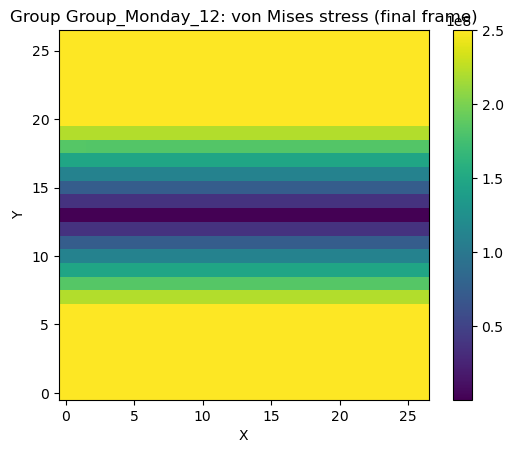

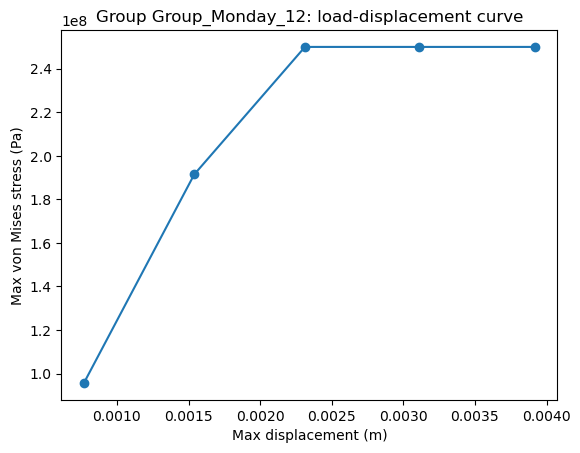

In [9]:
if __name__ == "__main__":

    def apply_grid_encoding(frame, grid_shape):
        Xi = frame["Xi"]
        origin = np.min(Xi, axis=0)
        geom = tuple(np.max(Xi, axis=0) - np.min(Xi, axis=0))
        grid_coords = grids.generate_grid(geom, grid_shape) + origin
        reduced = {
            k: v
            for k, v in frame.items()
            if "fenics" not in k and "bc_" not in k and isinstance(v, np.ndarray)
        }
        reduced.pop("Pi", None)
        _, _, enc = grids.grid_encode(grid_coords, grid_shape, Xi, reduced)
        return enc

    frames = [apply_grid_encoding(f, [27, 27]) for f in fe_history.values() if f]
    S = np.stack([f["Si"] for f in frames], axis=0)
    U = np.stack([f["Ui"] for f in frames], axis=0)
    mises_grid = fi.extract_stress_values(S, stress_type="mises")
    u_mag = np.linalg.norm(U, axis=-1)

    plt.figure()
    plt.title(f"Group {GROUP}: von Mises stress (final frame)")
    plt.imshow(mises_grid[-1].T, origin="lower")
    plt.colorbar()
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

    plt.figure()
    plt.title(f"Group {GROUP}: load-displacement curve")
    plt.plot(np.max(u_mag, axis=(1, 2)), np.max(mises_grid, axis=(1, 2)), "o-")
    plt.xlabel("Max displacement (m)")
    plt.ylabel("Max von Mises stress (Pa)")
    plt.show()